# Nutrition5K Data Exploration
This notebook is for exploring the Nutrition5K dataset and understanding what we have to work with.

In [ ]:
# ── Imports 
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Check for GPU
if torch.cuda.is_available():
    print("✓ GPU available:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print("✓ Apple Silicon GPU (MPS) available")
else:
    print("✗ No GPU found — running on CPU")
    print("  → On Kaggle: go to Session options (right sidebar) → Accelerator → GPU T4 x2")


✓ GPU available: Tesla T4


In [ ]:
# ── Set data paths ────────────────────────────────────────────────────────────
KAGGLE_ROOT = '/kaggle/input'
LOCAL_DATA  = 'data/archive'

if os.path.exists(KAGGLE_ROOT):
    # Walk all subdirectories to find where dish_nutrition_values.csv lives
    data_dir = None
    for root, dirs, files in os.walk(KAGGLE_ROOT):
        if 'dish_nutrition_values.csv' in files:
            data_dir = root
            break

    if data_dir is None:
        raise FileNotFoundError(
            "Could not find dish_nutrition_values.csv anywhere under /kaggle/input.\n"
            "Make sure the Nutrition5K dataset is added as an Input in the Kaggle sidebar."
        )
    print(f"✓ Kaggle: dataset found at '{data_dir}'")

else:
    data_dir = LOCAL_DATA
    print("✓ Local environment — using:", data_dir)

img_dir              = os.path.join(data_dir, 'imagery/realsense_overhead')
ingredients_csv      = os.path.join(data_dir, 'dish_ingredients.csv')
nutrition_csv        = os.path.join(data_dir, 'dish_nutrition_values.csv')
ingredients_meta_csv = os.path.join(data_dir, 'ingredients_metadata.csv')
print("✓ Data paths set:", data_dir)


✓ Kaggle: dataset found at '/kaggle/input/datasets/gillesokhin/nutrition5k-dataset'
✓ Data paths set: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset


In [ ]:
# ── Verify paths exist ────────────────────────────────────────────────────────
for label, path in [
    ("Image dir", img_dir),
    ("dish_ingredients.csv", ingredients_csv),
    ("dish_nutrition_values.csv", nutrition_csv),
    ("ingredients_metadata.csv", ingredients_meta_csv),
]:
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"{status}  {label}: {path}")


✓  Image dir: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead
✓  dish_ingredients.csv: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_ingredients.csv
✓  dish_nutrition_values.csv: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
✓  ingredients_metadata.csv: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/ingredients_metadata.csv


In [ ]:
# Checking out the CSV files
df_ingredients = pd.read_csv(ingredients_csv)
df_nutrition = pd.read_csv(nutrition_csv)
df_ingredients_meta = pd.read_csv(ingredients_meta_csv)
print('dish_ingredients.csv:')
display(df_ingredients.head())
print('dish_nutrition_values.csv:')
display(df_nutrition.head())
print('ingredients_metadata.csv:')
display(df_ingredients_meta.head())

dish_ingredients.csv:


,dish_id,ingr_id,ingr_name,grams,calories,fat,carb,protein
0,dish_1561662216,ingr_0000000508,soy sauce,3.398568,1.801241,0.020391,0.166530,0.275284
1,dish_1561662216,ingr_0000000122,garlic,2.124105,3.164916,0.010621,0.700955,0.135943
2,dish_1561662216,ingr_0000000026,white rice,8.496420,11.045346,0.025489,2.378998,0.229403
3,dish_1561662216,ingr_0000000524,parsley,0.213397,0.079170,0.001707,0.013657,0.006189
4,dish_1561662216,ingr_0000000094,onions,1.707173,0.682869,0.001707,0.153646,0.018779


dish_nutrition_values.csv:


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000


ingredients_metadata.csv:


,ingr_name,ingr_id,cal/g,fat(g),carb(g),protein(g)
0,cottage cheese,ingr_0000000001,0.980,0.043,0.034,0.110
1,strawberries,ingr_0000000002,0.330,0.003,0.080,0.007
2,garden salad,ingr_0000000003,0.646,0.034,0.032,0.061
3,bacon,ingr_0000000004,5.410,0.420,0.014,0.370
4,potatoes,ingr_0000000005,0.770,0.001,0.170,0.020


Total number of dish folders: 3490
Sample images in dish_1564588859: ['depth_raw.png', 'rgb.png', 'depth_color.png']


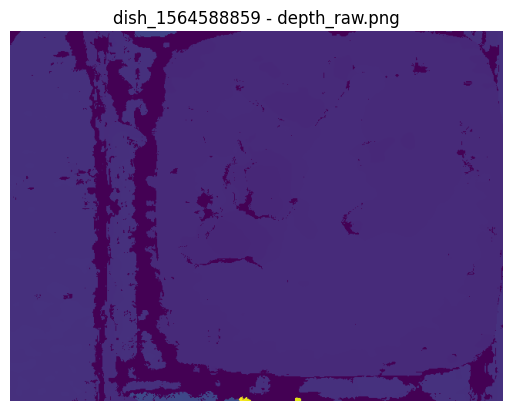

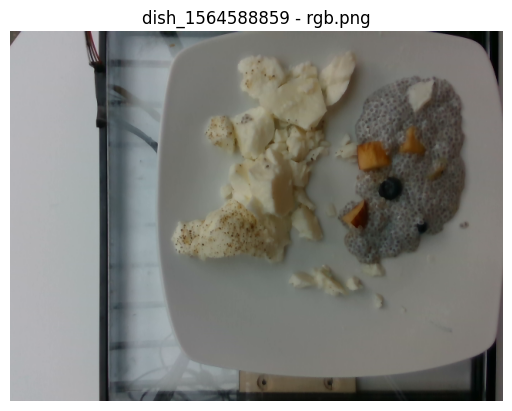

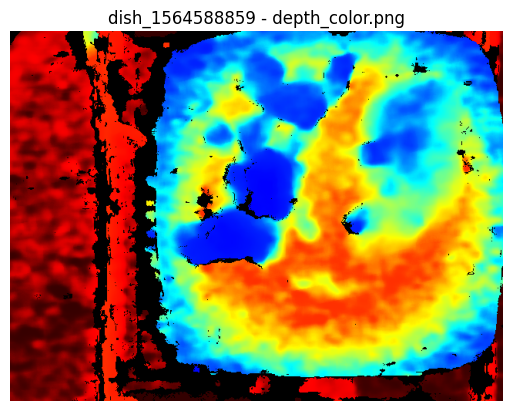

In [ ]:
# Let's see how many dishes and images we have
dish_folders = [f for f in os.listdir(img_dir) if f.startswith('dish_')]
print(f'Total number of dish folders: {len(dish_folders)}')
# Show a few sample images
sample_dish = dish_folders[0] if dish_folders else None
if sample_dish:
    sample_path = os.path.join(img_dir, sample_dish)
    sample_imgs = [f for f in os.listdir(sample_path) if f.endswith('.jpg') or f.endswith('.png')]
    print(f'Sample images in {sample_dish}:', sample_imgs[:3])
    for img_name in sample_imgs[:3]:
        img = Image.open(os.path.join(sample_path, img_name))
        plt.imshow(img)
        plt.title(f'{sample_dish} - {img_name}')
        plt.axis('off')
        plt.show()

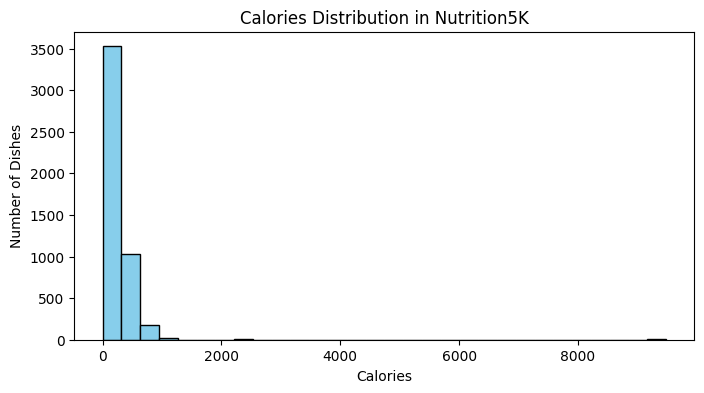

In [ ]:
# Checking the distribution of calories in the dataset
plt.figure(figsize=(8,4))
plt.hist(df_nutrition['calories'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Calories')
plt.ylabel('Number of Dishes')
plt.title('Calories Distribution in Nutrition5K')
plt.show()

## Phase 1 — Deep Data Exploration
Understanding the dataset structure, schema, missing values, and distributions before building any model.

In [ ]:
# ── 1. Schema & Shape ─────────────────────────────────────────────────────────
print("=" * 60)
print("dish_nutrition_values.csv")
print(f"  Shape : {df_nutrition.shape}")
print(f"  Columns: {list(df_nutrition.columns)}")
print()
print("dish_ingredients.csv")
print(f"  Shape : {df_ingredients.shape}")
print(f"  Columns: {list(df_ingredients.columns)}")
print()
print("ingredients_metadata.csv")
print(f"  Shape : {df_ingredients_meta.shape}")
print(f"  Columns: {list(df_ingredients_meta.columns)}")
print("=" * 60)


dish_nutrition_values.csv
  Shape : (4768, 6)
  Columns: ['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']

dish_ingredients.csv
  Shape : (27225, 8)
  Columns: ['dish_id', 'ingr_id', 'ingr_name', 'grams', 'calories', 'fat', 'carb', 'protein']

ingredients_metadata.csv
  Shape : (555, 6)
  Columns: ['ingr_name', 'ingr_id', 'cal/g', 'fat(g)', 'carb(g)', 'protein(g)']


In [ ]:
# ── 2. Missing Values ─────────────────────────────────────────────────────────
for name, df in [('dish_nutrition_values', df_nutrition),
                 ('dish_ingredients',      df_ingredients),
                 ('ingredients_metadata',  df_ingredients_meta)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"✓ {name}: no missing values")
    else:
        print(f"✗ {name}: missing values found:")
        print(missing)
    print()


✓ dish_nutrition_values: no missing values

✗ dish_ingredients: missing values found:
ingr_name    1
dtype: int64

✓ ingredients_metadata: no missing values



In [ ]:
# ── 3. Nutrition Statistics ───────────────────────────────────────────────────
# Identify numeric nutrient columns (exclude dish id / name columns)
nutrient_cols = df_nutrition.select_dtypes(include='number').columns.tolist()
print("Nutrient columns:", nutrient_cols)
display(df_nutrition[nutrient_cols].describe().round(2))


Nutrient columns: ['calories', 'mass', 'fat', 'carb', 'protein']


,calories,mass,fat,carb,protein
count,4768.00,4768.00,4768.00,4768.00,4768.00
mean,223.98,191.43,11.26,17.85,15.20
std,312.58,275.05,24.94,29.13,18.73
min,0.00,1.00,0.00,0.00,0.00
25%,60.95,72.00,0.62,5.12,1.68
50%,154.30,145.00,6.48,12.71,8.26
75%,324.40,260.00,16.06,24.20,22.48
max,9485.82,7975.00,875.54,844.57,147.49


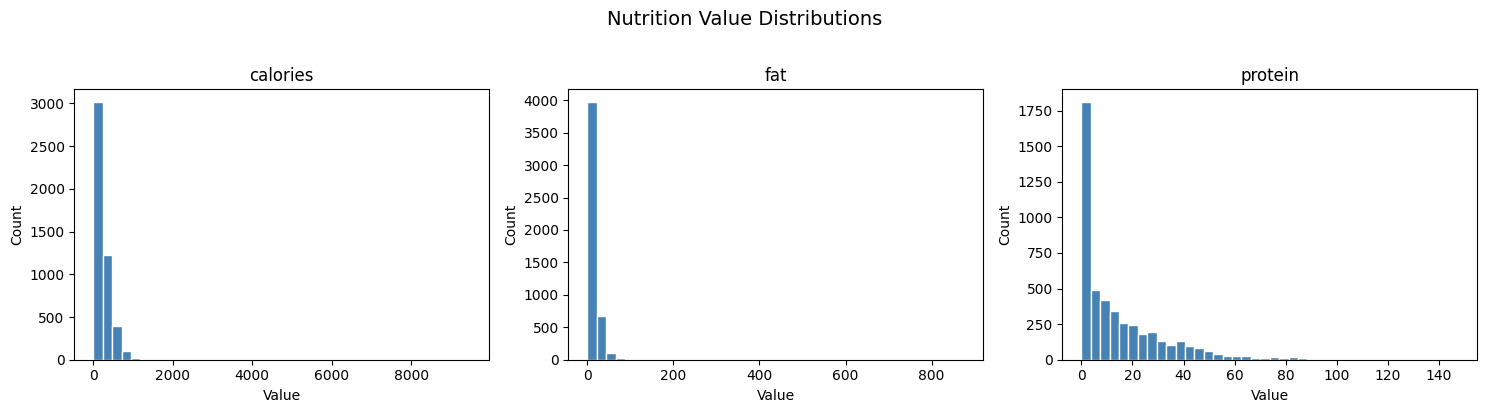

In [ ]:
# ── 4. Nutrition Distributions (calories, fat, protein, carbs) ────────────────
plot_cols = [c for c in ['calories', 'fat', 'protein', 'carbs', 'total_fat',
                         'total_carb', 'protein_g', 'fat_g', 'carb_g']
             if c in df_nutrition.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    ax.hist(df_nutrition[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Nutrition Value Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


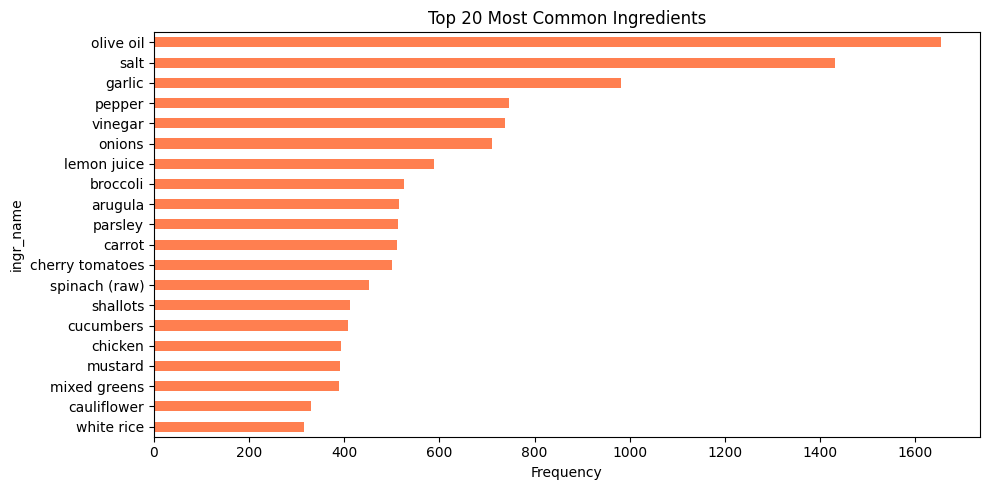

In [ ]:
# ── 5. Top Ingredients by Frequency ──────────────────────────────────────────
# Find the ingredient name column (try common names)
name_col = next((c for c in df_ingredients.columns
                 if 'name' in c.lower() or 'ingredient' in c.lower()), None)

if name_col:
    top_ingredients = df_ingredients[name_col].value_counts().head(20)
    plt.figure(figsize=(10, 5))
    top_ingredients.plot(kind='barh', color='coral')
    plt.xlabel('Frequency')
    plt.title('Top 20 Most Common Ingredients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Could not find ingredient name column. Columns:", list(df_ingredients.columns))


Images per dish — min: 0, max: 3, avg: 3.0
Image width  — min: 640, max: 640
Image height — min: 480, max: 480


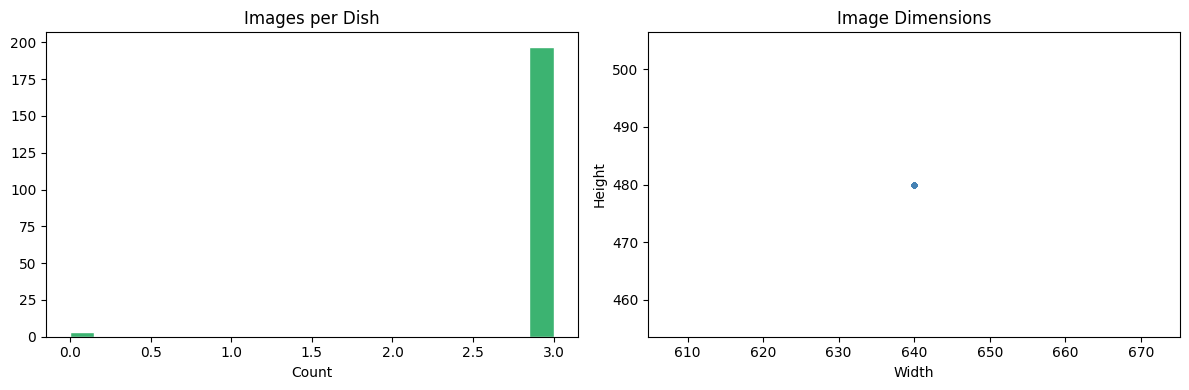

In [ ]:
# ── 6. Images per Dish & Image Size Check ────────────────────────────────────
img_counts = []
img_sizes  = []

for dish in dish_folders[:200]:  # sample 200 dishes for speed
    dish_path = os.path.join(img_dir, dish)
    imgs = [f for f in os.listdir(dish_path) if f.endswith(('.jpg', '.png'))]
    img_counts.append(len(imgs))
    # Check size of the first image
    if imgs:
        with Image.open(os.path.join(dish_path, imgs[0])) as im:
            img_sizes.append(im.size)  # (width, height)

widths  = [s[0] for s in img_sizes]
heights = [s[1] for s in img_sizes]

print(f"Images per dish — min: {min(img_counts)}, max: {max(img_counts)}, avg: {sum(img_counts)/len(img_counts):.1f}")
print(f"Image width  — min: {min(widths)}, max: {max(widths)}")
print(f"Image height — min: {min(heights)}, max: {max(heights)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(img_counts, bins=20, color='mediumseagreen', edgecolor='white')
ax1.set_title('Images per Dish')
ax1.set_xlabel('Count')
ax2.scatter(widths, heights, alpha=0.3, s=10, color='steelblue')
ax2.set_title('Image Dimensions')
ax2.set_xlabel('Width')
ax2.set_ylabel('Height')
plt.tight_layout()
plt.show()


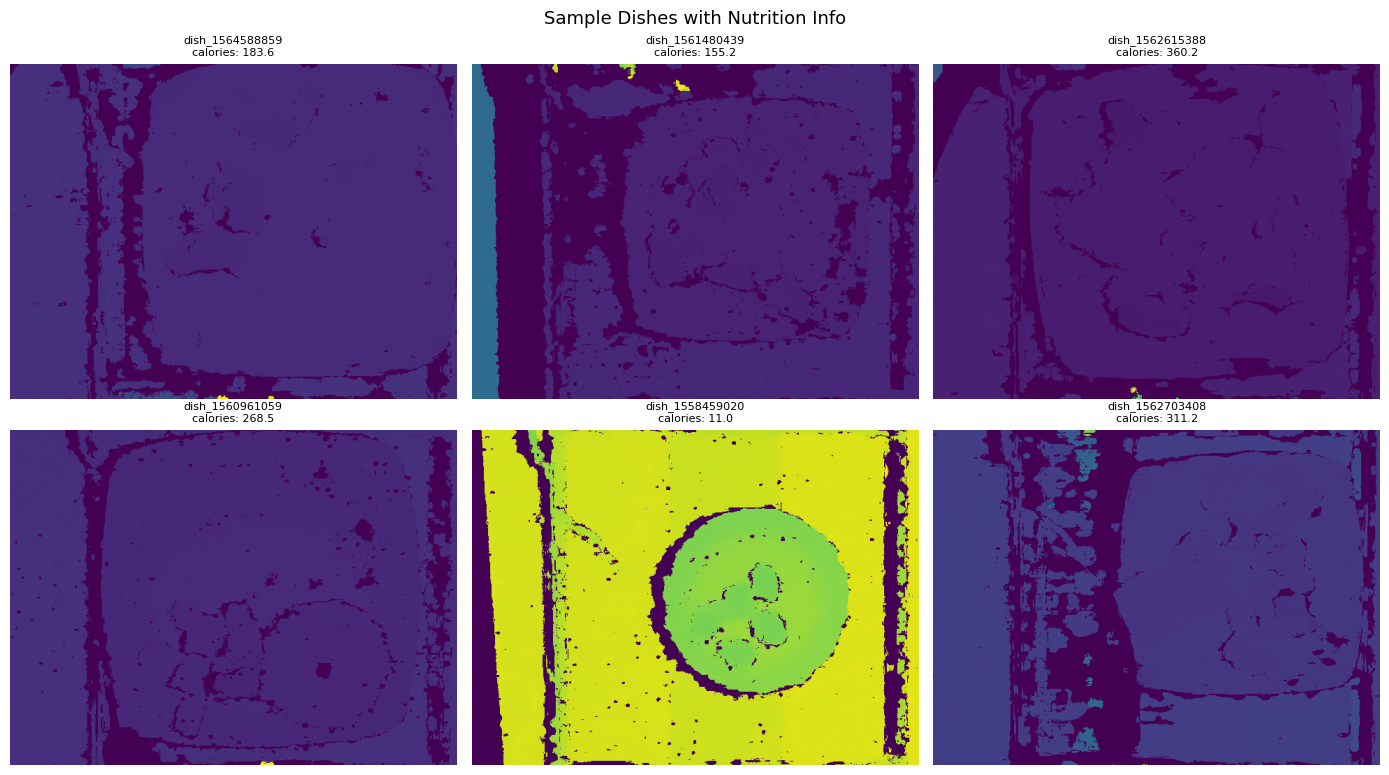

In [ ]:
# ── 7. Sample Images with Nutrition Labels ───────────────────────────────────
# Find the dish ID column in df_nutrition
dish_id_col = df_nutrition.columns[0]  # usually first column

# Build a quick lookup: dish_id -> nutrition row
nutrition_lookup = df_nutrition.set_index(dish_id_col)

cal_col = next((c for c in df_nutrition.columns if 'calor' in c.lower()), None)

n_samples = 6
sample_dishes = dish_folders[:n_samples]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, dish in zip(axes, sample_dishes):
    dish_path = os.path.join(img_dir, dish)
    imgs = [f for f in os.listdir(dish_path) if f.endswith(('.jpg', '.png'))]
    if not imgs:
        ax.axis('off')
        continue
    img = Image.open(os.path.join(dish_path, imgs[0]))
    ax.imshow(img)
    ax.axis('off')

    # Build title with calories if available
    if cal_col and dish in nutrition_lookup.index:
        cal = nutrition_lookup.loc[dish, cal_col]
        ax.set_title(f"{dish}\n{cal_col}: {cal:.1f}", fontsize=8)
    else:
        ax.set_title(dish, fontsize=8)

plt.suptitle('Sample Dishes with Nutrition Info', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 8. Phase 1 Summary ───────────────────────────────────────────────────────
print("=" * 60)
print("PHASE 1 SUMMARY")
print("=" * 60)
print(f"  Total dishes (image folders) : {len(dish_folders)}")
print(f"  Nutrition rows               : {len(df_nutrition)}")
print(f"  Ingredient rows              : {len(df_ingredients)}")
print(f"  Ingredient metadata rows     : {len(df_ingredients_meta)}")
if cal_col:
    print(f"  Calorie range                : {df_nutrition[cal_col].min():.1f} – {df_nutrition[cal_col].max():.1f}")
    print(f"  Calorie mean ± std           : {df_nutrition[cal_col].mean():.1f} ± {df_nutrition[cal_col].std():.1f}")
print("=" * 60)
print("✓ Phase 1 complete — ready for Phase 2: Dataset & DataLoader")


PHASE 1 SUMMARY
  Total dishes (image folders) : 3490
  Nutrition rows               : 4768
  Ingredient rows              : 27225
  Ingredient metadata rows     : 555
  Calorie range                : 0.0 – 9485.8
  Calorie mean ± std           : 224.0 ± 312.6
✓ Phase 1 complete — ready for Phase 2: Dataset & DataLoader
